# Hacker News event-discourse collection

**Observed window:** September 8-30, 2026. Uses the public Hacker News Algolia search index for stories and comments.

This is a query-defined source sample, not a census of social-media sentiment. It is intentionally separate from the AI-equity event-study notebook.

In [1]:
from pathlib import Path
import html, json, re
import numpy as np
import pandas as pd
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

START, END = '2026-09-08', '2026-10-01'  # END is exclusive; includes Sep. 30
RAW = Path('data/raw'); RAW.mkdir(parents=True, exist_ok=True)
analyzer = SentimentIntensityAnalyzer()
NEG = re.compile(r'\b(risk|risks|danger|dangerous|warning|warns|kill|killing|death|doom|catastroph|existential|threat|fear|panic|alarm|wipe out|humanity)\b', re.I)
POS = re.compile(r'\b(safe|safety|benefit|opportunity|growth|progress|solution|guardrail|optimism|improve)\b', re.I)

def score_daily(posts):
    if posts.empty:
        return pd.DataFrame()
    posts = posts.copy()
    posts['date'] = pd.to_datetime(posts['date'], utc=True).dt.tz_localize(None).dt.normalize()
    posts = posts.loc[(posts.date >= pd.Timestamp(START)) & (posts.date < pd.Timestamp(END))].drop_duplicates('id')
    posts['compound'] = posts.text.map(lambda x: analyzer.polarity_scores(str(x))['compound'])
    posts['risk_intensity'] = posts.text.map(lambda x: (len(NEG.findall(str(x))) - len(POS.findall(str(x)))) / max(1, len(str(x).split())))
    posts['engagement'] = 1 + posts.likes + posts.replies + posts.quotes + posts.reposts
    return posts, posts.groupby('date').agg(posts=('id', 'size'), compound=('compound', 'mean'), risk_intensity=('risk_intensity', 'mean'))


In [2]:
CACHE = RAW / 'hackernews_2026-09-08_2026-10-01.json'
URL = 'https://hn.algolia.com/api/v1/search_by_date'
QUERIES = ['Evan Hubinger', 'Jacob Coxon', 'Anthropic AI risk', 'Anthropic alignment']

def collect_hackernews():
    if CACHE.exists():
        return json.loads(CACHE.read_text())
    rows, errors = [], []
    lower, upper = int(pd.Timestamp(f'{START}T00:00:00Z').timestamp()), int(pd.Timestamp(f'{END}T00:00:00Z').timestamp())
    for query in QUERIES:
        try:
            r = requests.get(URL, params={'query':query, 'tags':'(story,comment)', 'hitsPerPage':100, 'numericFilters':f'created_at_i>={lower},created_at_i<{upper}'}, headers={'User-Agent':'academic-event-study/1.0'}, timeout=30)
            r.raise_for_status()
            for hit in r.json().get('hits', []):
                text = html.unescape(re.sub(r'<[^>]+>', ' ', hit.get('comment_text') or hit.get('story_title') or hit.get('title') or ''))
                item_id = hit.get('objectID')
                rows.append({'id':f'hn-{item_id}', 'date':hit.get('created_at'), 'text':text, 'author':hit.get('author',''), 'url':f'https://news.ycombinator.com/item?id={item_id}', 'likes':hit.get('points') or 0, 'replies':hit.get('num_comments') or 0, 'quotes':0, 'reposts':0})
        except requests.RequestException as exc:
            errors.append(f'{query}: {exc}')
    payload = {'metadata':{'queries':QUERIES, 'start':START, 'end_exclusive':END, 'retrieved_utc':pd.Timestamp.now(tz='UTC').isoformat(), 'errors':errors}, 'rows':rows}
    CACHE.write_text(json.dumps(payload, ensure_ascii=False, indent=2))
    return payload

payload = collect_hackernews()
posts = pd.DataFrame(payload['rows'])
if posts.empty:
    print('No Hacker News observations collected:', payload['metadata'].get('errors', []))
else:
    posts, daily = score_daily(posts)
    print(payload['metadata']); display(daily)


{'queries': ['Evan Hubinger', 'Jacob Coxon', 'Anthropic AI risk', 'Anthropic alignment'], 'start': '2026-09-08', 'end_exclusive': '2026-10-01', 'retrieved_utc': '2026-09-30T21:33:53.739334+00:00', 'errors': []}


,posts,compound,risk_intensity
date,,,
2026-09-08,3,0.197267,0.003584
2026-09-09,25,-0.008688,0.020589
2026-09-10,18,-0.279739,0.020060
2026-09-11,7,-0.059400,0.031867
2026-09-12,29,0.133817,0.004542
2026-09-13,14,-0.179571,0.006130
2026-09-14,8,-0.380213,0.027597
2026-09-15,4,0.430175,0.006579
2026-09-16,9,-0.109289,0.006838


## Source-level event-study analysis

The analysis below is conditional on returned observations. It uses the same equal-weight AI basket as the original study: NVDA, META, AMZN, GOOGL, MSFT, AVGO, and TSM, benchmarked against SPY. The one-lag Granger diagnostics are exploratory: source coverage is query-defined and the event window is very short.


,value
unique posts,211.000000
covered calendar days,23.000000
mean unweighted compound,-0.034992
mean risk intensity,0.016314
median engagement,1.000000
basket cumulative return,0.028835
SPY cumulative return,-0.001875


,date,author,text,url,engagement,compound,risk_intensity
22,2026-09-08,frgturpwd,I think this easily could have been me if I di...,https://news.ycombinator.com/item?id=49608555,1,0.8068,0.000000
23,2026-09-08,throw-qqqqq,There is huge logistics involved in killing a ...,https://news.ycombinator.com/item?id=49607750,1,-0.8519,0.010753
21,2026-09-08,Bluestein,"Hey, maybe the scariest part of this is that, ...",https://news.ycombinator.com/item?id=49614982,1,0.6369,0.000000
220,2026-09-09,nothrowaways,More than 10% probability AI will wipe out hum...,https://news.ycombinator.com/item?id=49621712,5,0.0000,0.166667
151,2026-09-09,slowin,> “I do agree that the public has a negative ...,https://news.ycombinator.com/item?id=49629327,1,-0.7747,0.019802
152,2026-09-09,lenerdenator,"The risks of AI, while mostly hypothetical, ha...",https://news.ycombinator.com/item?id=49628337,1,-0.5023,0.020619
153,2026-09-09,barnabee,This Already powerful and wealthy organisation...,https://news.ycombinator.com/item?id=49628172,1,-0.3491,0.025000
154,2026-09-09,thiago_fm,How about we instead make Earth be a planet go...,https://news.ycombinator.com/item?id=49627829,1,-0.9337,0.000000
155,2026-09-09,dgellow,"> Like any economic model, this one has limits...",https://news.ycombinator.com/item?id=49627154,1,0.5864,0.022472
156,2026-09-09,shafyy,Not saying that the current civilizations will...,https://news.ycombinator.com/item?id=49625397,1,-0.8807,0.014493


,posts,compound,risk_intensity,engagement_weighted_compound,basket_return,basket_excess_return
Date,,,,,,
2026-09-09,25,-0.0087,0.0206,-0.0353,-0.0016,0.0031
2026-09-10,18,-0.2797,0.0201,-0.0827,-0.0084,-0.0024
2026-09-11,7,-0.0594,0.0319,-0.3111,0.0091,0.0006
2026-09-14,8,-0.3802,0.0276,-0.2792,-0.0077,-0.0032
2026-09-15,4,0.4302,0.0066,0.4909,-0.0090,-0.0044
2026-09-16,9,-0.1093,0.0068,-0.1824,-0.0006,0.0038
2026-09-17,7,-0.1476,-0.0042,-0.1476,0.0200,0.0087
2026-09-18,9,-0.0549,0.0169,-0.0549,0.0052,0.0039
2026-09-21,6,0.1617,-0.0013,0.1617,0.0315,0.0161


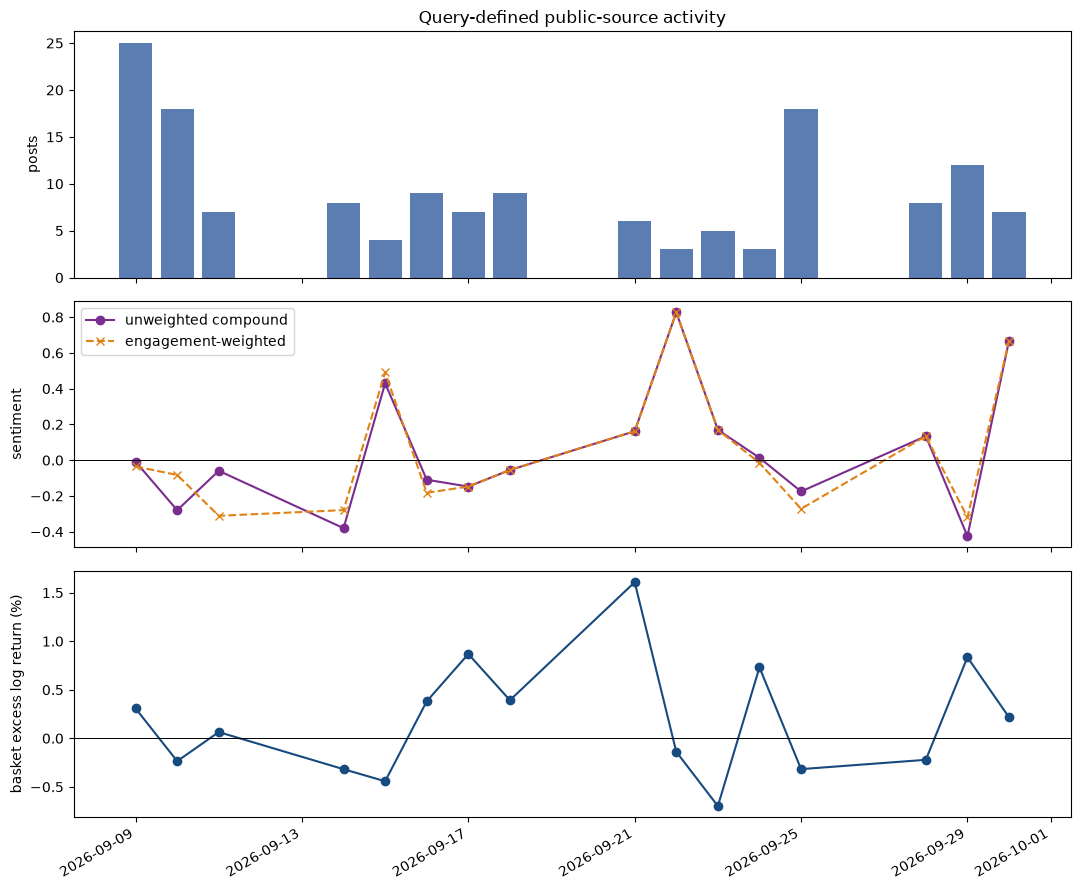

,lag-1 F-test p-value
compound -> excess return,0.654283
risk intensity -> excess return,0.448352
post count -> excess return,0.767994
weighted compound -> excess return,0.715943


Interpretation: p-values are descriptive low-power diagnostics, not causal estimates. A zero on a no-post trading day means no observed sample activity, not neutral public sentiment.


In [3]:
import warnings
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import grangercausalitytests

if posts.empty:
    print('Analysis skipped because this source returned no observations.')
else:
    # Add an engagement-weighted score as sensitivity only; the unweighted score is primary.
    weighted = posts.groupby('date').apply(
        lambda d: np.average(d['compound'], weights=d['engagement'])
    ).rename('engagement_weighted_compound')
    daily_analysis = daily.join(weighted)

    TICKERS = ['NVDA', 'META', 'AMZN', 'GOOGL', 'MSFT', 'AVGO', 'TSM']
    closes = yf.download(TICKERS + ['SPY'], start=START, end=END,
                         auto_adjust=True, progress=False)['Close']
    returns = np.log(closes).diff().dropna()
    returns['basket_return'] = returns[TICKERS].mean(axis=1)
    returns['basket_excess_return'] = returns['basket_return'] - returns['SPY']

    panel = pd.DataFrame(index=returns.index).join(daily_analysis).fillna({
        'posts': 0, 'compound': 0, 'risk_intensity': 0,
        'engagement_weighted_compound': 0,
    }).join(returns[['basket_return', 'basket_excess_return']])

    summary = pd.Series({
        'unique posts': len(posts),
        'covered calendar days': int((daily_analysis['posts'] > 0).sum()),
        'mean unweighted compound': posts['compound'].mean(),
        'mean risk intensity': posts['risk_intensity'].mean(),
        'median engagement': posts['engagement'].median(),
        'basket cumulative return': np.exp(returns['basket_return'].sum()) - 1,
        'SPY cumulative return': np.exp(returns['SPY'].sum()) - 1,
    })
    display(summary.to_frame('value'))
    display(posts[['date', 'author', 'text', 'url', 'engagement', 'compound', 'risk_intensity']].sort_values('date').head(20))
    display(panel.round(4))

    fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    ax[0].bar(panel.index, panel['posts'], color='#5b7db1')
    ax[0].set_ylabel('posts')
    ax[0].set_title('Query-defined public-source activity')
    ax[1].plot(panel.index, panel['compound'], marker='o', color='#7b2d8e', label='unweighted compound')
    ax[1].plot(panel.index, panel['engagement_weighted_compound'], marker='x', linestyle='--', color='#e08214', label='engagement-weighted')
    ax[1].axhline(0, color='black', linewidth=.7); ax[1].legend(); ax[1].set_ylabel('sentiment')
    ax[2].plot(panel.index, 100 * panel['basket_excess_return'], marker='o', color='#174a7e')
    ax[2].axhline(0, color='black', linewidth=.7); ax[2].set_ylabel('basket excess log return (%)')
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()

    def granger_pvalue(driver):
        sample = panel[['basket_excess_return', driver]].dropna()
        if len(sample) < 8 or sample[driver].nunique() < 2:
            return np.nan
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            result = grangercausalitytests(sample, maxlag=1)
        return result[1][0]['ssr_ftest'][1]

    granger = pd.Series({
        'compound -> excess return': granger_pvalue('compound'),
        'risk intensity -> excess return': granger_pvalue('risk_intensity'),
        'post count -> excess return': granger_pvalue('posts'),
        'weighted compound -> excess return': granger_pvalue('engagement_weighted_compound'),
    }, name='lag-1 F-test p-value')
    display(granger.to_frame())
    print('Interpretation: p-values are descriptive low-power diagnostics, not causal estimates. A zero on a no-post trading day means no observed sample activity, not neutral public sentiment.')


## Results-based interpretation

### What the Hacker News sample says

The fixed-query collector returned **211 unique Hacker News stories/comments** across **23 calendar days** from September 8 through September 30 (the notebook's `END` date is exclusive). The sample is therefore sustained rather than a one-day burst, but activity is uneven: the highest daily counts were 29 posts on September 12, 25 on September 9, and 19 on September 25. The initial September 8 date has only three observations, so it should not be used to characterize a platform-wide opening-day reaction.

Across all collected observations, mean VADER compound sentiment is **-0.035** and mean risk intensity is **0.0163**. Read together, these show mildly negative, risk-tilted language on average - not uniformly catastrophic discourse. Tone changes materially from day to day: the trading-day mean is most negative on September 29 (-0.425, 12 posts), September 14 (-0.380, eight posts), and September 10 (-0.280, 18 posts), while September 30 (+0.668, seven posts), September 15 (+0.430, four posts), and September 22 (+0.827, three posts) are positive but thin. September 27 remains a weekend observation and is excluded from the trading-day return panel; September 29 and September 30 are now paired with their completed market returns.

### Market comparison

For the **16 aligned trading observations** (September 9-30), the equal-weight AI basket compounded **+2.88%** while SPY compounded **-0.19%**. The basket's positive window-level performance coexists with several negative Hacker News sentiment days. That pattern is inconsistent with a simple claim that more negative discussion mechanically depressed AI equities. It does not demonstrate the opposite: daily returns also reflect broad-market, macroeconomic, earnings, and company-specific information that this bivariate exercise does not control for.

### Granger diagnostics

None of the four one-lag tests rejects the no-predictive-content null for next-day basket excess return: unweighted compound sentiment **p = 0.654**, risk intensity **p = 0.448**, post count **p = 0.768**, and engagement-weighted compound sentiment **p = 0.716**. The most cautious reading is that this query-defined Hacker News sample supplies **no detectable incremental predictive signal** for next-day AI-basket excess returns in this short window. These are not tests of structural causality and have low power with 16 aligned days; non-rejection is not evidence that discussion has no economic relevance.

### Interpretation limits

Hacker News is a technically oriented, self-selected community, not a representative cross-section of investors or the public. The collector mixes comments and stories, and the four fixed search phrases preferentially retrieve risk- and Anthropic-related discussion. VADER and the transparent lexicon may miss sarcasm, technical nuance, and quoted language; the median observed engagement is only 1, so engagement-weighted results should be treated as a sensitivity check rather than a primary measure. The appropriate conclusion is source-specific: Hacker News discussion was episodically negative and risk-oriented, but this sample does not show a reliable lagged association with the selected AI basket's excess returns.


## Interpretation

Use source-level daily counts and sentiment only with the displayed query, date window, and collection metadata. Do not pool this sample with another platform without preserving the source label and explaining the selection rule.